In [1]:
import pandas as pd
import numpy as np

# Importing dataset from previous external research, news dataset, classification task
url = "https://raw.githubusercontent.com/FrancescaRomanaBlanda/Taboo-Language/main/haspeede2_reference_taskAB-news.tsv"

df_ABnews = pd.read_csv(url, sep='\t', encoding='utf-8', header=None,
    names=["id", "context", "offensiveness", "stereotype"]
)
 
df_ABnews.insert(0, 'sentence_id', range(len(df_ABnews)))

df_ABnews.head()

,sentence_id,id,context,offensiveness,stereotype
0,0,11976,"Andate pure là, tanto quei fessi degli italian...",1,0
1,1,12142,Che fine spero che faccia il killer nigeriano ...,1,1
2,2,12088,Così i profughi ci svuotano i negozi a Pordenone,1,1
3,3,12030,Così umiliano gli italiani e coccolano i cland...,1,1
4,4,11775,"Danno soldi ai clandestini, ma ai disabili inv...",1,1


In [2]:
# Importing dataset from previous external research, tweets dataset, classification task
url = "https://raw.githubusercontent.com/FrancescaRomanaBlanda/Taboo-Language/main/haspeede2_reference_taskAB-tweets.tsv"

df_ABtweets = pd.read_csv(url, sep='\t', encoding='utf-8',  header=None,
    names=["id", "context", "offensiveness", "stereotype"])

df_ABtweets.insert(0, 'sentence_id', range(len(df_ABtweets)))
 
df_ABtweets.head()

,sentence_id,id,context,offensiveness,stereotype
0,0,11834,@user A me pare una scelta politica suicida pu...,1,0
1,1,12113,@user e' un perfetto musulmano!!! chi dice il ...,1,1
2,2,11770,Mai Tg e i giornaloni hanno parlato di questa ...,1,1
3,3,11937,@user Ipocriti farabutti. Fanno morire i terre...,1,1
4,4,11870,@user @user @user L'IMMIGRAZIONE C'E' STATO UN...,1,1


In [3]:
# Importing dataset from previous external research, news dataset, hate-span task
url = "https://raw.githubusercontent.com/FrancescaRomanaBlanda/Taboo-Language/main/haspeede2_reference_taskC-news.txt"

df_Cnews = pd.read_csv(url, sep='\t', encoding='utf-8', comment="#",
    header=None,
    names=["token_id", "word", "tag"], engine="python", quoting=3)

df_Cnews.insert(0, 'sentence_id', range(len(df_Cnews)))
 
df_Cnews.head()

,sentence_id,token_id,word,tag
0,0,11976-1,"""",O
1,1,11976-2,Andate,O
2,2,11976-3,pure,O
3,3,11976-4,là,O
4,4,11976-5,",",O


In [4]:
# Importing dataset from previous external research, tweets dataset, hate-span task
url = "https://raw.githubusercontent.com/FrancescaRomanaBlanda/Taboo-Language/main/haspeede2_reference_taskC-tweets.txt"

df_Ctweets = pd.read_csv(url, sep='\t', encoding='utf-8',comment="#",
    header=None,
    names=["token_id", "word", "tag"], engine="python", quoting=3)

df_Ctweets.insert(0, 'sentence_id', range(len(df_Ctweets)))
 
df_Ctweets.head()

,sentence_id,token_id,word,tag
0,0,11834-1,@,O
1,1,11834-2,user,O
2,2,11834-3,A,O
3,3,11834-4,me,O
4,4,11834-5,pare,O


In [5]:
# Creating the offensive_span column by joining the "B" and "I" of the BIO tags into one line, tweets dataset, hate-span task
df_Ctweets['id'] = df_Ctweets['token_id'].str.split('-').str[0].astype(int)

df_ABCtweets = df_Ctweets[df_Ctweets['tag'].isin(['B-NU-CGA', 'I-NU-CGA'])]

spans = (
    df_ABCtweets
    .groupby('id')['word']
    .apply(lambda x: ' '.join(x))
    .reset_index()
    .rename(columns={'word': 'offensive_span'})
)

# Merging classification with hate-span task for tweets dataset
merged_dftweets = df_ABtweets.merge(spans, on='id', how='left')
merged_dftweets.head(10)

,sentence_id,id,context,offensiveness,stereotype,offensive_span
0,0,11834,@user A me pare una scelta politica suicida pu...,1,0,"Meglio così ,"
1,1,12113,@user e' un perfetto musulmano!!! chi dice il ...,1,1,NaN
2,2,11770,Mai Tg e i giornaloni hanno parlato di questa ...,1,1,"Sanremo , Segregata e stuprata per mesi . La g..."
3,3,11937,@user Ipocriti farabutti. Fanno morire i terre...,1,1,Ipocriti farabutti .
4,4,11870,@user @user @user L'IMMIGRAZIONE C'E' STATO UN...,1,1,NaN
5,5,12122,@user @user SI CERTO E TUTTIQUELLI CHE GIRANO ...,1,1,ESPATRIOOOOOOO . . . . BASTAAAAAA
6,6,12095,Ha ragione! É il corano che prescrive la lotta...,1,1,NaN
7,7,11609,Per quanto mi riguarda l'accogliere indiscrimi...,1,1,"Migranti , Fico :"
8,8,12141,IO DOMANDO A QUESTE MERDE che vogliono e accet...,1,1,NaN
9,9,11868,Eccerto poverini poi i migranti si incattivisc...,1,1,NaN


In [6]:
# Creating the offensive_span column by joining the "B" and "I" of the BIO tags into one line, news dataset, hate-span task
df_Cnews['id'] = df_Cnews['token_id'].str.split('-').str[0].astype(int)

df_ABCnews = df_Cnews[df_Cnews['tag'].isin(['B-NU-CGA', 'I-NU-CGA'])]

spans = (
    df_ABCnews
    .groupby('id')['word']
    .apply(lambda x: ' '.join(x))
    .reset_index()
    .rename(columns={'word': 'offensive_span'})
)

# Merging classification with hate-span task for news dataset
merged_dfnews = df_ABnews.merge(spans, on='id', how='left')
merged_dfnews.head(10)

,sentence_id,id,context,offensiveness,stereotype,offensive_span
0,0,11976,"Andate pure là, tanto quei fessi degli italian...",1,0,NaN
1,1,12142,Che fine spero che faccia il killer nigeriano ...,1,1,La furia cieca della Meloni : le sue parole pi...
2,2,12088,Così i profughi ci svuotano i negozi a Pordenone,1,1,NaN
3,3,12030,Così umiliano gli italiani e coccolano i cland...,1,1,"La follia del governo : "" Per loro gratis . . ..."
4,4,11775,"Danno soldi ai clandestini, ma ai disabili inv...",1,1,"Bracconeri , il figlio autistico e il durissim..."
5,5,11630,"Emergenza, Minniti annulla il viaggio e torna ...",1,1,"Emergenza , Immigrati , invasione alle porte :..."
6,6,11695,"Gli immigrati sono matti, parola di scienziati...",1,1,"parola di scienziati . Malattie mentali e "" ri..."
7,7,11866,Ho chiesto ai profughi di lavorare ma preferis...,1,1,NaN
8,8,12174,Immigrati bomba sociale Subito via 600mila irr...,1,1,""" Immigrati bomba sociale Subito via 600mila i..."
9,9,11663,"Immigrati, così la sinistra ci costringe a ten...",1,1,"Immigrati , Meloni , la denuncia : "" Il trucco..."


In [7]:
# Merging news and tweets datasets, "Language" column added
merged_df = pd.concat([merged_dfnews, merged_dftweets], ignore_index=True)
merged_df.insert(1, 'Language', 'ITA')
merged_df = merged_df.drop(columns=['id'])
merged_df.head(100)

,sentence_id,Language,context,offensiveness,stereotype,offensive_span
0,0,ITA,"Andate pure là, tanto quei fessi degli italian...",1,0,NaN
1,1,ITA,Che fine spero che faccia il killer nigeriano ...,1,1,La furia cieca della Meloni : le sue parole pi...
2,2,ITA,Così i profughi ci svuotano i negozi a Pordenone,1,1,NaN
3,3,ITA,Così umiliano gli italiani e coccolano i cland...,1,1,"La follia del governo : "" Per loro gratis . . ..."
4,4,ITA,"Danno soldi ai clandestini, ma ai disabili inv...",1,1,"Bracconeri , il figlio autistico e il durissim..."
...,...,...,...,...,...,...
95,95,ITA,Il migrante adolescente morto in mare con la p...,0,0,NaN
96,96,ITA,"Latina, centinaia di stranieri sfruttati nei c...",0,0,NaN
97,97,ITA,"Morta Maritsa, la nonna di Lesbo che allattava...",0,0,NaN
98,98,ITA,Al corteo per Matera Capitale della cultura i ...,0,0,NaN


In [8]:
# Modified column notation according to the standard set for comparison with Sinhala and Korean
merged_df['offensiveness'] = merged_df['offensiveness'].fillna(0).astype(int)

def map_stereotype(row):
    if row['stereotype'] == 0 and row['offensiveness'] == 0:
        return "null"
    elif row['stereotype'] == 1:
        return "GRP"
    else:
        return "IND"

merged_df['stereotype'] = merged_df.apply(map_stereotype, axis=1)
merged_df['offensiveness'] = merged_df['offensiveness'].fillna('NOT')
merged_df['offensiveness'] = merged_df['offensiveness'].map({1: 'OFF', 0: 'NOT'})
merged_df = merged_df.rename(columns={'stereotype': 'target_type'})
merged_df.head(100)

,sentence_id,Language,context,offensiveness,target_type,offensive_span
0,0,ITA,"Andate pure là, tanto quei fessi degli italian...",OFF,IND,NaN
1,1,ITA,Che fine spero che faccia il killer nigeriano ...,OFF,GRP,La furia cieca della Meloni : le sue parole pi...
2,2,ITA,Così i profughi ci svuotano i negozi a Pordenone,OFF,GRP,NaN
3,3,ITA,Così umiliano gli italiani e coccolano i cland...,OFF,GRP,"La follia del governo : "" Per loro gratis . . ..."
4,4,ITA,"Danno soldi ai clandestini, ma ai disabili inv...",OFF,GRP,"Bracconeri , il figlio autistico e il durissim..."
...,...,...,...,...,...,...
95,95,ITA,Il migrante adolescente morto in mare con la p...,NOT,null,NaN
96,96,ITA,"Latina, centinaia di stranieri sfruttati nei c...",NOT,null,NaN
97,97,ITA,"Morta Maritsa, la nonna di Lesbo che allattava...",NOT,null,NaN
98,98,ITA,Al corteo per Matera Capitale della cultura i ...,NOT,null,NaN


In [9]:
# Added the "target_group_attribute" column, checking dataset entries
merged_df.insert(merged_df.columns.get_loc('target_type')+1, 'target_group_attribute', np.nan)
merged_df.head(100)

,sentence_id,Language,context,offensiveness,target_type,target_group_attribute,offensive_span
0,0,ITA,"Andate pure là, tanto quei fessi degli italian...",OFF,IND,NaN,NaN
1,1,ITA,Che fine spero che faccia il killer nigeriano ...,OFF,GRP,NaN,La furia cieca della Meloni : le sue parole pi...
2,2,ITA,Così i profughi ci svuotano i negozi a Pordenone,OFF,GRP,NaN,NaN
3,3,ITA,Così umiliano gli italiani e coccolano i cland...,OFF,GRP,NaN,"La follia del governo : "" Per loro gratis . . ..."
4,4,ITA,"Danno soldi ai clandestini, ma ai disabili inv...",OFF,GRP,NaN,"Bracconeri , il figlio autistico e il durissim..."
...,...,...,...,...,...,...,...
95,95,ITA,Il migrante adolescente morto in mare con la p...,NOT,null,NaN,NaN
96,96,ITA,"Latina, centinaia di stranieri sfruttati nei c...",NOT,null,NaN,NaN
97,97,ITA,"Morta Maritsa, la nonna di Lesbo che allattava...",NOT,null,NaN,NaN
98,98,ITA,Al corteo per Matera Capitale della cultura i ...,NOT,null,NaN,NaN


In [10]:
# Created a csv file to feed to ChatGPT annotator for target_group_attribute classification according to previously chosen categories
merged_df[["context", "target_group_attribute"]].to_csv(
    "context_target_group_attribute.csv",
    index=False
)

In [11]:
# Imported annotated output and counted categories of target_group_attribute instances
url = "https://raw.githubusercontent.com/FrancescaRomanaBlanda/Taboo-Language/refs/heads/main/Italian/context_target_group_attribute_labeled_v4%20(1).csv"

df_tga = pd.read_csv(url)

counts = df_tga["target_group_attribute"].value_counts()

print(counts)

target_group_attribute
Immigrants                       1193
Religion                          217
Race, Ethnicity & Nationality     187
Gender & Sexual Orientation        88
Political Affiliation              31
Miscellaneous                      26
Nomads                             15
Socioeconomic status                6
Name: count, dtype: int64


In [12]:
# Imported annotated output and counted categories of target_group instances
url = "https://raw.githubusercontent.com/FrancescaRomanaBlanda/Taboo-Language/refs/heads/main/Italian/context_target_group_attribute_labeled_v4_with_target_group.csv"

df_tg = pd.read_csv(url)

counts = df_tg["target_group"].value_counts()

print(counts)

target_group
Immigrants             1193
Others                  212
Islam                   190
Men                      57
Roma                     32
Other political          30
lgbtq+                   14
Nomads (general)         11
Other socioeconomic       6
Black                     5
Roma/Travellers           4
Chinese                   4
Christianity              2
Women                     1
Right-wing                1
Arab                      1
Name: count, dtype: int64


In [13]:
# Checking "offensiveness" value counts
counts=merged_df["offensiveness"].value_counts()
print(counts)

offensiveness
NOT    960
OFF    803
Name: count, dtype: int64


In [14]:
# Adding "target_group_attribute" column to main dataframe
merged_df["target_group_attribute"] = df_tga["target_group_attribute"]

merged_df.head(100)

,sentence_id,Language,context,offensiveness,target_type,target_group_attribute,offensive_span
0,0,ITA,"Andate pure là, tanto quei fessi degli italian...",OFF,IND,Miscellaneous,NaN
1,1,ITA,Che fine spero che faccia il killer nigeriano ...,OFF,GRP,Political Affiliation,La furia cieca della Meloni : le sue parole pi...
2,2,ITA,Così i profughi ci svuotano i negozi a Pordenone,OFF,GRP,Immigrants,NaN
3,3,ITA,Così umiliano gli italiani e coccolano i cland...,OFF,GRP,Immigrants,"La follia del governo : "" Per loro gratis . . ..."
4,4,ITA,"Danno soldi ai clandestini, ma ai disabili inv...",OFF,GRP,Immigrants,"Bracconeri , il figlio autistico e il durissim..."
...,...,...,...,...,...,...,...
95,95,ITA,Il migrante adolescente morto in mare con la p...,NOT,null,Immigrants,NaN
96,96,ITA,"Latina, centinaia di stranieri sfruttati nei c...",NOT,null,Immigrants,NaN
97,97,ITA,"Morta Maritsa, la nonna di Lesbo che allattava...",NOT,null,Immigrants,NaN
98,98,ITA,Al corteo per Matera Capitale della cultura i ...,NOT,null,Immigrants,NaN


In [15]:
# Adding "target_group" column to main dataframe, fixing columns layout
merged_df["target_group"] = df_tg["target_group"]

cols = list(merged_df.columns)
new_pos = cols.index("target_group_attribute") + 1
cols.insert(new_pos, cols.pop(cols.index("target_group")))
merged_df = merged_df[cols]
merged_df.head(100)

,sentence_id,Language,context,offensiveness,target_type,target_group_attribute,target_group,offensive_span
0,0,ITA,"Andate pure là, tanto quei fessi degli italian...",OFF,IND,Miscellaneous,Others,NaN
1,1,ITA,Che fine spero che faccia il killer nigeriano ...,OFF,GRP,Political Affiliation,Other political,La furia cieca della Meloni : le sue parole pi...
2,2,ITA,Così i profughi ci svuotano i negozi a Pordenone,OFF,GRP,Immigrants,Immigrants,NaN
3,3,ITA,Così umiliano gli italiani e coccolano i cland...,OFF,GRP,Immigrants,Immigrants,"La follia del governo : "" Per loro gratis . . ..."
4,4,ITA,"Danno soldi ai clandestini, ma ai disabili inv...",OFF,GRP,Immigrants,Immigrants,"Bracconeri , il figlio autistico e il durissim..."
...,...,...,...,...,...,...,...,...
95,95,ITA,Il migrante adolescente morto in mare con la p...,NOT,null,Immigrants,Immigrants,NaN
96,96,ITA,"Latina, centinaia di stranieri sfruttati nei c...",NOT,null,Immigrants,Immigrants,NaN
97,97,ITA,"Morta Maritsa, la nonna di Lesbo che allattava...",NOT,null,Immigrants,Immigrants,NaN
98,98,ITA,Al corteo per Matera Capitale della cultura i ...,NOT,null,Immigrants,Immigrants,NaN


In [16]:
# Find rows where context span contains 'rom' (case insensitive, handles NaN safely)
mask = merged_df["context"].str.contains(r"\brom\b", case=False, na=False)

# Reassigning those values to "Nomads" label
merged_df.loc[mask, "target_group_attribute"] = "Nomads"
merged_df.loc[mask, "target_group"] = "Nomads (general)"

merged_df["target_group"] = merged_df["target_group"].replace(
    "Nomads (general)", 
    "Nomads"
)

# Fixing label notation
merged_df["target_group"] = merged_df["target_group"].replace(
    "lgbtq+", 
    "LGBTQ+"
)
merged_df.head(100)

,sentence_id,Language,context,offensiveness,target_type,target_group_attribute,target_group,offensive_span
0,0,ITA,"Andate pure là, tanto quei fessi degli italian...",OFF,IND,Miscellaneous,Others,NaN
1,1,ITA,Che fine spero che faccia il killer nigeriano ...,OFF,GRP,Political Affiliation,Other political,La furia cieca della Meloni : le sue parole pi...
2,2,ITA,Così i profughi ci svuotano i negozi a Pordenone,OFF,GRP,Immigrants,Immigrants,NaN
3,3,ITA,Così umiliano gli italiani e coccolano i cland...,OFF,GRP,Immigrants,Immigrants,"La follia del governo : "" Per loro gratis . . ..."
4,4,ITA,"Danno soldi ai clandestini, ma ai disabili inv...",OFF,GRP,Immigrants,Immigrants,"Bracconeri , il figlio autistico e il durissim..."
...,...,...,...,...,...,...,...,...
95,95,ITA,Il migrante adolescente morto in mare con la p...,NOT,null,Immigrants,Immigrants,NaN
96,96,ITA,"Latina, centinaia di stranieri sfruttati nei c...",NOT,null,Immigrants,Immigrants,NaN
97,97,ITA,"Morta Maritsa, la nonna di Lesbo che allattava...",NOT,null,Immigrants,Immigrants,NaN
98,98,ITA,Al corteo per Matera Capitale della cultura i ...,NOT,null,Immigrants,Immigrants,NaN


In [17]:
# Created a csv file from the final dataset
merged_df.to_csv("final_dataframe.csv", index=False)

In [18]:
# EDA for Italian Taboo Sentences
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import re

Category counts:
target_group_attribute
Immigrants                       1162
Nomads                            267
Religion                          214
Gender & Sexual Orientation        74
Miscellaneous                      26
Political Affiliation              16
Socioeconomic status                3
Race, Ethnicity & Nationality       1
Name: count, dtype: int64


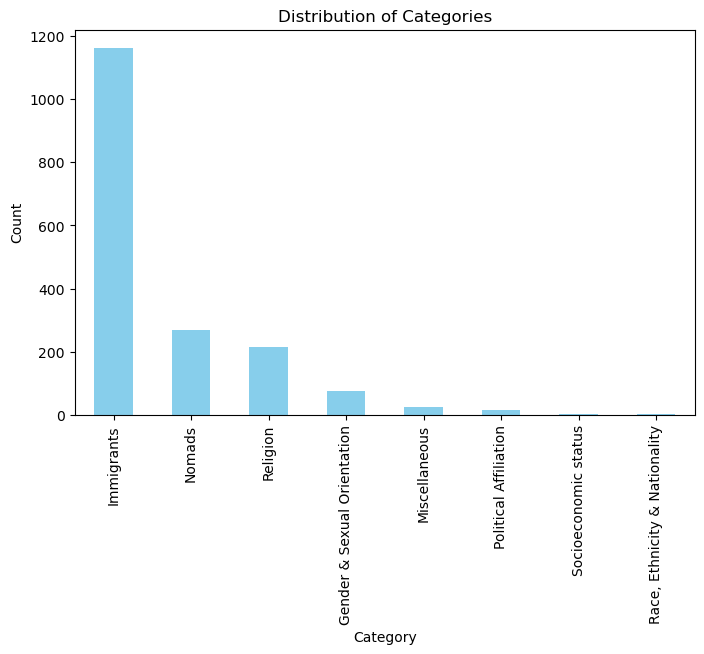

In [19]:
# Category Frequency
print("Category counts:")
print(merged_df["target_group_attribute"].value_counts())

plt.figure(figsize=(8,5))
merged_df["target_group_attribute"].value_counts().plot(kind="bar", color="skyblue")
plt.title("Distribution of Categories")
plt.ylabel("Count")
plt.xlabel("Category")
plt.show()

In [20]:
# Cross Analysis: Attribute × Target Group
print("\nCross-tab of Attribute vs Target Group:")
print(pd.crosstab(merged_df["target_group"], merged_df["target_group_attribute"]))


Cross-tab of Attribute vs Target Group:
target_group_attribute  Gender & Sexual Orientation  Immigrants  \
target_group                                                      
Black                                             0           0   
Christianity                                      0           0   
Immigrants                                        0        1162   
Islam                                             0           0   
LGBTQ+                                           13           0   
Men                                              52           0   
Nomads                                            0           0   
Other political                                   0           0   
Other socioeconomic                               0           0   
Others                                            8           0   
Right-wing                                        0           0   
Roma/Travellers                                   0           0   
Women                

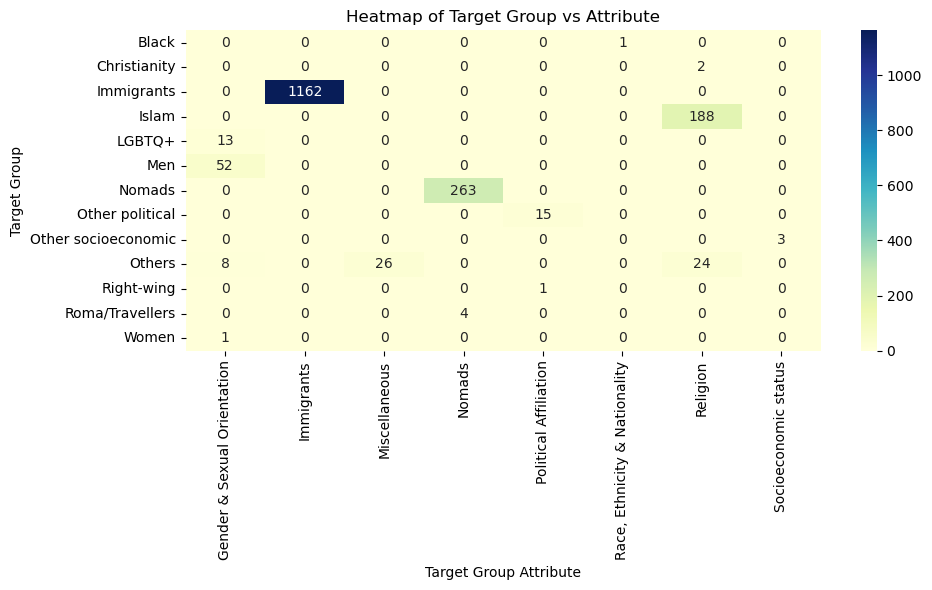

In [ ]:
# Heatmap of Cross Analysis: Attribute × Target Group
plt.figure(figsize=(10, 6))
sns.heatmap(
    pd.crosstab(
        merged_df["target_group"],
        merged_df["target_group_attribute"]
    ),
    annot=True,
    fmt="d",
    cmap="YlGnBu"
)
plt.title("Heatmap of Target Group vs Attribute")
plt.xlabel("Target Group Attribute")
plt.ylabel("Target Group")
plt.tight_layout()
plt.show()

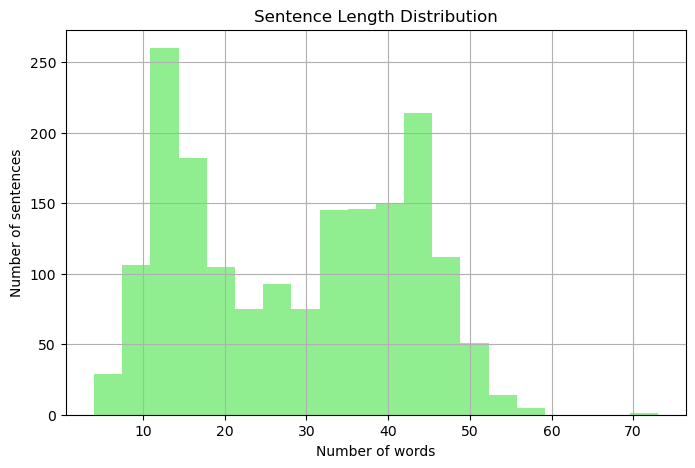

In [22]:
# Sentence Length Analysis
merged_df["length"] = merged_df["context"].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(8,5))
merged_df["length"].hist(bins=20, color="lightgreen")
plt.title("Sentence Length Distribution")
plt.xlabel("Number of words")
plt.ylabel("Number of sentences")
plt.show()

In [23]:
# Mean sentence length per category
print("\nMean sentence length per category:")
print(merged_df.groupby("target_group_attribute")["length"].mean())


Mean sentence length per category:
target_group_attribute
Gender & Sexual Orientation      32.716216
Immigrants                       26.733219
Miscellaneous                    26.153846
Nomads                           31.599251
Political Affiliation            36.562500
Race, Ethnicity & Nationality    14.000000
Religion                         32.500000
Socioeconomic status             31.000000
Name: length, dtype: float64


In [24]:
# Class Imbalance Check
print("\nNormalized class distribution:")
print(merged_df["target_group_attribute"].value_counts(normalize=True))


Normalized class distribution:
target_group_attribute
Immigrants                       0.659104
Nomads                           0.151446
Religion                         0.121384
Gender & Sexual Orientation      0.041974
Miscellaneous                    0.014748
Political Affiliation            0.009075
Socioeconomic status             0.001702
Race, Ethnicity & Nationality    0.000567
Name: proportion, dtype: float64


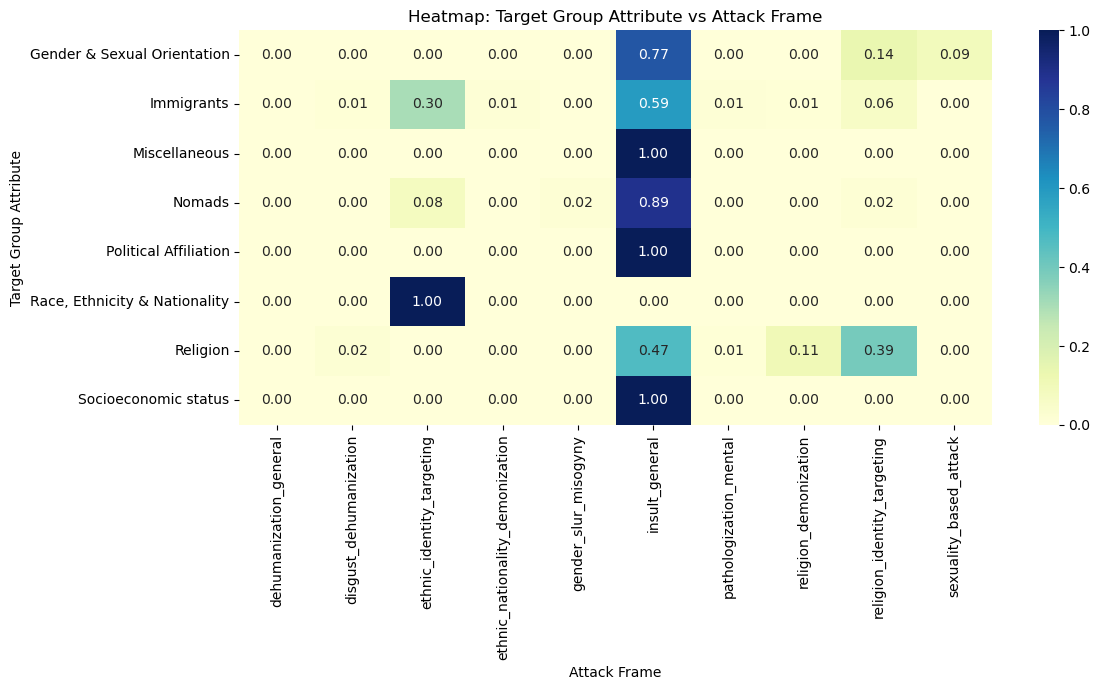

In [ ]:
import seaborn as sns

# Load annotated dataset by ChatGPT annotator
df = pd.read_csv("annotated_attack_frames_refined.csv")

# Create Heatmap of Target Group Attribute vs Attack Frame
cross_tab_norm = pd.crosstab(
    df["target_group_attribute"],
    df["attack_frame_refined"],
    normalize="index"
)

plt.figure(figsize=(12, 7))
sns.heatmap(cross_tab_norm, annot=True, fmt=".2f", cmap="YlGnBu")

plt.title("Heatmap: Target Group Attribute vs Attack Frame")
plt.xlabel("Attack Frame")
plt.ylabel("Target Group Attribute")

plt.tight_layout()
plt.show()

c:\Users\duebl\anaconda3\Lib\site-packages\sklearn\manifold\_mds.py:298: FutureWarning: The default value of `normalized_stress` will change to `'auto'` in version 1.4. To suppress this warning, manually set the value of `normalized_stress`.
  warnings.warn(


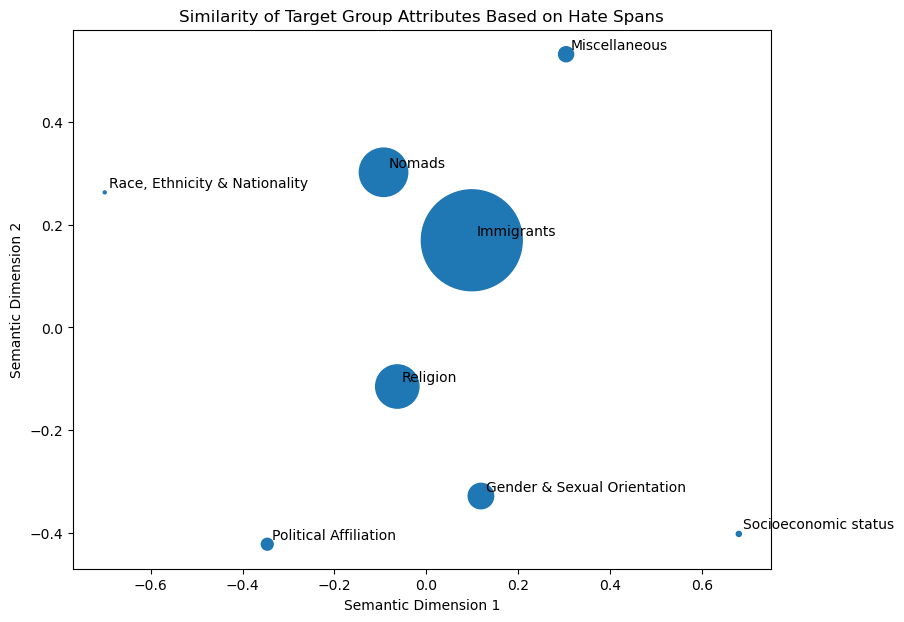

In [25]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_distances
from sklearn.manifold import MDS

# Visualize similarity between target group attributes based on the language used in offensive spans
category_texts = (
    merged_df
    .dropna(subset=["offensive_span"])
    .groupby("target_group_attribute")["offensive_span"]
    .apply(lambda x: " ".join(x.astype(str)))
)

categories = category_texts.index
texts = category_texts.values

proportions = merged_df["target_group_attribute"].value_counts(normalize=True).reindex(categories)

vectorizer = TfidfVectorizer(
    stop_words="english",
    min_df=2
)

X = vectorizer.fit_transform(texts)

dist = cosine_distances(X)

mds = MDS(n_components=2, dissimilarity="precomputed", random_state=42)
coords = mds.fit_transform(dist)

plt.figure(figsize=(9,7))

plt.scatter(
    coords[:,0],
    coords[:,1],
    s=proportions.values * 8000
)

for i, label in enumerate(categories):
    plt.text(coords[i,0]+0.01, coords[i,1]+0.01, label, fontsize=10)

plt.title("Similarity of Target Group Attributes Based on Hate Spans")
plt.xlabel("Semantic Dimension 1")
plt.ylabel("Semantic Dimension 2")

plt.show()

c:\Users\duebl\anaconda3\Lib\site-packages\sklearn\manifold\_mds.py:298: FutureWarning: The default value of `normalized_stress` will change to `'auto'` in version 1.4. To suppress this warning, manually set the value of `normalized_stress`.
  warnings.warn(


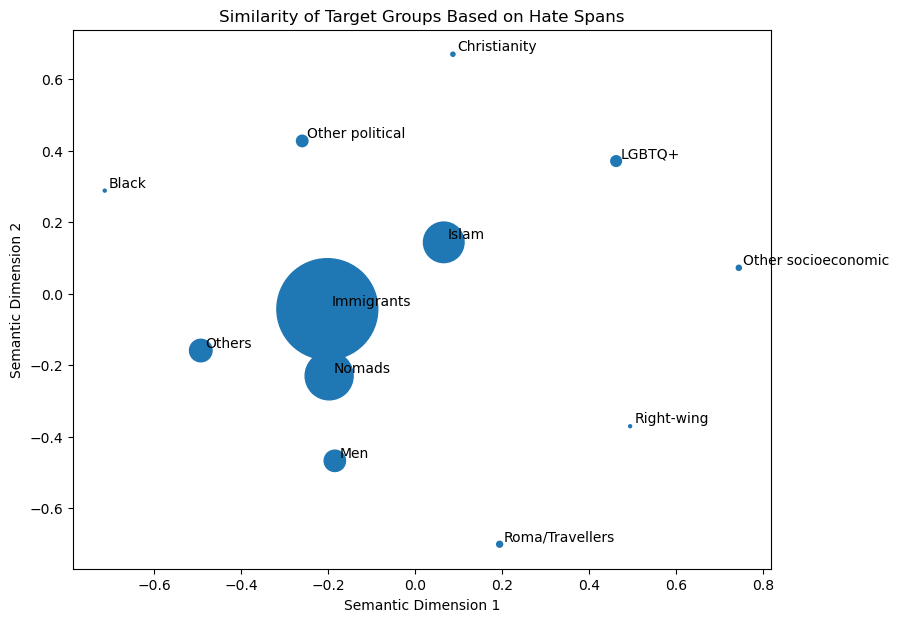

In [26]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_distances
from sklearn.manifold import MDS

# Visualize similarity between target groups based on the language used in offensive spans
category_texts = (
    merged_df
    .dropna(subset=["offensive_span"])
    .groupby("target_group")["offensive_span"]
    .apply(lambda x: " ".join(x.astype(str)))
)

categories = category_texts.index
texts = category_texts.values

proportions = merged_df["target_group"].value_counts(normalize=True).reindex(categories)

vectorizer = TfidfVectorizer(
    stop_words="english",
    min_df=2
)

X = vectorizer.fit_transform(texts)

dist = cosine_distances(X)

mds = MDS(n_components=2, dissimilarity="precomputed", random_state=42)
coords = mds.fit_transform(dist)

plt.figure(figsize=(9,7))

plt.scatter(
    coords[:,0],
    coords[:,1],
    s=proportions.values * 8000
)

for i, label in enumerate(categories):
    plt.text(coords[i,0]+0.01, coords[i,1]+0.01, label, fontsize=10)

plt.title("Similarity of Target Groups Based on Hate Spans")
plt.xlabel("Semantic Dimension 1")
plt.ylabel("Semantic Dimension 2")

plt.show()

<Axes: title={'center': 'sentence_length'}, xlabel='offensiveness'>

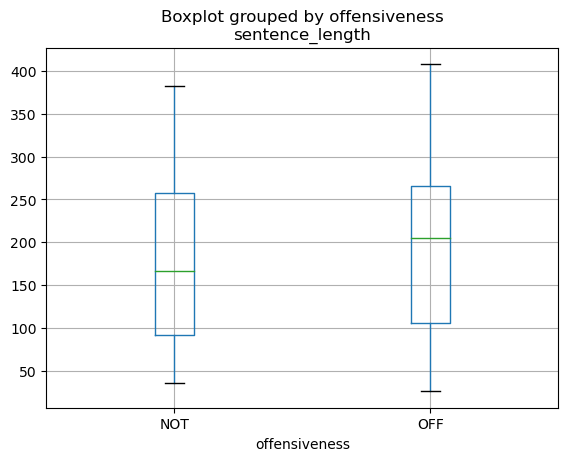

In [27]:
# Boxplot of sentence length grouped by offensiveness label
merged_df["sentence_length"] = merged_df["context"].str.len()

merged_df.boxplot(column="sentence_length", by="offensiveness")

## Appendix

In [28]:
# First method: initial attempt to label target_group_attribute by training a model
import json
import requests

# Importing the italian hate speech dataset to train the model with
base_url = "https://raw.githubusercontent.com/dhfbk/MuLTa-Telegram/main/data/it"

def load_json_file(filename):
    full_url = f"{base_url}/{filename}"
    response = requests.get(full_url)
    response.raise_for_status()  
    data = response.json()
    return pd.DataFrame(data)

train_df = load_json_file("train.json")
dev_df = load_json_file("dev.json")
test_df = load_json_file("test.json")

print(train_df.columns)
print(train_df.head())

Index(['id', 'text', 'hate label', 'hate target', 'mentioned group', 'split',
       'language'],
      dtype='object')
   id                                               text  hate label  \
0   1                       Mah che c'è ne frega a noi ?           0   
1   2  che idioti....cmq, se avessero rifiutato di ve...           1   
2   3  È possibile...al governo ci sono molti nazisti...           0   
3   4  <photo>  Sul profilo ufficiale Instagram del p...           0   
4   5  #Italia #Elezioni2022  Il diciassettesimo part...           0   

  hate target           mentioned group  split language  
0                                  None  train       it  
1       Other  Migrants;People of color  train       it  
2                                  Jews  train       it  
3                                  Jews  train       it  
4                                LGBTQ+  train       it  


In [29]:
# Checking the dataset
print(train_df.columns)
print(train_df.head(10))
print(train_df['hate target'].value_counts())

Index(['id', 'text', 'hate label', 'hate target', 'mentioned group', 'split',
       'language'],
      dtype='object')
   id                                               text  hate label  \
0   1                       Mah che c'è ne frega a noi ?           0   
1   2  che idioti....cmq, se avessero rifiutato di ve...           1   
2   3  È possibile...al governo ci sono molti nazisti...           0   
3   4  <photo>  Sul profilo ufficiale Instagram del p...           0   
4   5  #Italia #Elezioni2022  Il diciassettesimo part...           0   
5   6  Rifiuta la fascia arcobaleno “per motivi relig...           0   
6   7  <video>  Vera Sharav 75° Anniversario Norimber...           0   
7   8  <video>  A Mosca, nel 18° anniversario della t...           0   
8   9  A che punto sono le indagini relative allo spy...           0   
9  10  👍🏻👍🏻👍🏻prendiamo nota di nome e cognome come di...           0   

  hate target           mentioned group  split language  
0                            

In [30]:
# Map original dataset labels to labels defined for this study
mapping = {
    "LGBTQ+": "Gender & Sexual Orientation",
    "Women": "Gender & Sexual Orientation",
    "Ethnicity/ Origin: people of color": "Race, Ethnicity & Nationality",
    "Ethnicity/ Origin: romani": "Race, Ethnicity & Nationality",
    "Jewish": "Religion",
    "Muslims": "Religion",
    "Christians": "Religion",
    "Other": "Miscellaneous",
    "Ethnicity/ Origin: other": "Race, Ethnicity & Nationality",
    "No target": "Miscellaneous",
    "Disability": "Disability"
}

In [31]:
# Map dataset target labels to the target_group_attribute categories
def map_target(row):
    target = row['mentioned group']
    if pd.isna(target) or str(target).strip() == "" or str(target).lower() == "none":
        target = row['hate target']
    if pd.isna(target) or str(target).strip() == "" or str(target).lower() == "no target":
        return "Miscellaneous"
    if target in mapping:
        return mapping[target]
    else:
        return "Miscellaneous"

for df in [train_df, dev_df, test_df]:
    df['target_group_attribute'] = df.apply(map_target, axis=1)

In [32]:
# Checking a sample
train_df[['text','hate target','mentioned group','target_group_attribute']].head(10)
train_df['target_group_attribute'].value_counts()

target_group_attribute
Miscellaneous                    790
Gender & Sexual Orientation      206
Religion                         119
Race, Ethnicity & Nationality      6
Name: count, dtype: int64

In [33]:
# pip install transformers datasets torch scikit-learn

In [34]:
# Import libraries
from datasets import Dataset, DatasetDict
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score
import torch

ImportError: cannot import name 'HfFolder' from 'huggingface_hub' (c:\Users\duebl\anaconda3\Lib\site-packages\huggingface_hub\__init__.py)

In [ ]:
# Prepare the training, validation, and test datasets; encode labels for model training
train_data = train_df[['text', 'target_group_attribute']]
dev_data   = dev_df[['text', 'target_group_attribute']]
test_data  = test_df[['text', 'target_group_attribute']]

label_encoder = LabelEncoder()
train_data['label'] = label_encoder.fit_transform(train_data['target_group_attribute'])
dev_data['label'] = label_encoder.transform(dev_data['target_group_attribute'])
test_data['label'] = label_encoder.transform(test_data['target_group_attribute'])

hf_train = Dataset.from_pandas(train_data[['text', 'label']])
hf_dev   = Dataset.from_pandas(dev_data[['text', 'label']])
hf_test  = Dataset.from_pandas(test_data[['text', 'label']])

dataset = DatasetDict({
    'train': hf_train,
    'validation': hf_dev,
    'test': hf_test
})

print(dataset)

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 1121
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 181
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 700
    })
})


C:\Users\duebl\AppData\Local\Temp\ipykernel_22712\3990160914.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_data['label'] = label_encoder.fit_transform(train_data['target_group_attribute'])
C:\Users\duebl\AppData\Local\Temp\ipykernel_22712\3990160914.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dev_data['label'] = label_encoder.transform(dev_data['target_group_attribute'])
C:\Users\duebl\AppData\Local\Temp\ipykernel_22712\3990160914.py:11: SettingWithCopyWarning: 
A value is trying to be 

In [ ]:
# Import libraries
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

In [ ]:
# Initialize the XLM-RoBERTa tokenizer and sequence classification model
model_name = "xlm-roberta-base"

tokenizer = AutoTokenizer.from_pretrained(model_name)

num_labels = len(label_encoder.classes_)

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=num_labels
)

C:\Users\duebl\anaconda3\Lib\site-packages\huggingface_hub\file_download.py:943: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.out_proj.bias', 'classifier.out_proj.weight', 'classifier.dense.weight', 'classifier.dense.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
# Tokenize the input text for the model
def tokenize(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

In [ ]:
# Apply tokenization to the entire dataset
tokenized_dataset = dataset.map(
     tokenize,
     batched=True
 )

Map:   0%|          | 0/1121 [00:00<?, ? examples/s]

Map:   0%|          | 0/181 [00:00<?, ? examples/s]

Map:   0%|          | 0/700 [00:00<?, ? examples/s]

In [ ]:
# Remove raw text and format the dataset for PyTorch training
tokenized_dataset = tokenized_dataset.remove_columns(["text"])
tokenized_dataset.set_format("torch")

In [ ]:
# Import libraries
import numpy as np
from sklearn.metrics import f1_score, accuracy_score

In [ ]:
# Define evaluation metrics (accuracy and macro F1) for model performance
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    return {
        "accuracy": accuracy_score(labels, preds),
        "macro_f1": f1_score(labels, preds, average="macro")
    }

In [ ]:
# Configure training parameters for the classifier
training_args = TrainingArguments(
    output_dir="./hate_category_model",
    evaluation_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=4,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    logging_steps=100,
    save_total_limit=2,
    report_to="none"
)

In [ ]:
# Initialize the Trainer with the model, datasets, tokenizer, and evaluation metrics
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    tokenizer=tokenizer,
    compute_metrics=compute_metrics
)

C:\Users\duebl\anaconda3\Lib\site-packages\accelerate\accelerator.py:457: FutureWarning: Passing the following arguments to `Accelerator` is deprecated and will be removed in version 1.0 of Accelerate: dict_keys(['dispatch_batches']). Please pass an `accelerate.DataLoaderConfiguration` instead: 
dataloader_config = DataLoaderConfiguration(dispatch_batches=None)
  warnings.warn(


In [ ]:
# Train the model
trainer.train()

C:\Users\duebl\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
You're using a XLMRobertaTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,No log,0.694084,0.740331,0.376315
2,0.818600,0.364575,0.883978,0.651380
3,0.345100,0.338947,0.889503,0.654211
4,0.345100,0.336096,0.906077,0.669117


C:\Users\duebl\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
C:\Users\duebl\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
C:\Users\duebl\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


TrainOutput(global_step=284, training_loss=0.4853449136438504, metrics={'train_runtime': 12961.3665, 'train_samples_per_second': 0.346, 'train_steps_per_second': 0.022, 'total_flos': 294952789487616.0, 'train_loss': 0.4853449136438504, 'epoch': 4.0})

In [ ]:
# Evaluate the trained model on the test dataset
trainer.evaluate(tokenized_dataset["test"])

C:\Users\duebl\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


{'eval_loss': 0.27108076214790344,
 'eval_accuracy': 0.9057142857142857,
 'eval_macro_f1': 0.6580245140893153,
 'eval_runtime': 105.0621,
 'eval_samples_per_second': 6.663,
 'eval_steps_per_second': 0.419,
 'epoch': 4.0}

In [ ]:
# Apply the trained classifier to predict missing target_group_attribute labels
merged_df["context"] = merged_df["context"].fillna("").astype(str)
unlabeled_ds = Dataset.from_pandas(
    merged_df[['context']].rename(columns={'context': 'text'})
)
tokenized_unlabeled = unlabeled_ds.map(
    tokenize,
    batched=True
)
tokenized_unlabeled.set_format("torch")
predictions = trainer.predict(tokenized_unlabeled)
pred_labels = np.argmax(predictions.predictions, axis=1)
merged_df["predicted_category"] = label_encoder.inverse_transform(pred_labels)

# Use model confidence to filter unreliable predictions
merged_df["confidence"] = predictions.predictions.max(axis=1)
merged_df.loc[
    merged_df["target_type"] == "IND",
    "predicted_category"
] = "Miscellaneous"
merged_df.loc[
    merged_df["confidence"] < 0.5,
    "predicted_category"
] = "Miscellaneous"


Map:   0%|          | 0/1763 [00:00<?, ? examples/s]

C:\Users\duebl\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


In [ ]:
# Assign the predicted categories to the target_group_attribute field and check the results
merged_df["target_group_attribute"] = merged_df["predicted_category"]
merged_df.head(100)

,sentence_id,Language,context,offensiveness,target_type,target_group_attribute,target_group,offensive_span,predicted_category,confidence
0,0,ITA,"Andate pure là, tanto quei fessi degli italian...",OFF,IND,Miscellaneous,Others,NaN,Miscellaneous,4.395621
1,1,ITA,Che fine spero che faccia il killer nigeriano ...,OFF,GRP,Miscellaneous,Other political,La furia cieca della Meloni : le sue parole pi...,Miscellaneous,4.181208
2,2,ITA,Così i profughi ci svuotano i negozi a Pordenone,OFF,GRP,Miscellaneous,Immigrants,NaN,Miscellaneous,3.795964
3,3,ITA,Così umiliano gli italiani e coccolano i cland...,OFF,GRP,Miscellaneous,Immigrants,"La follia del governo : "" Per loro gratis . . ...",Miscellaneous,4.359488
4,4,ITA,"Danno soldi ai clandestini, ma ai disabili inv...",OFF,GRP,Miscellaneous,Immigrants,"Bracconeri , il figlio autistico e il durissim...",Miscellaneous,4.206936
...,...,...,...,...,...,...,...,...,...,...
95,95,ITA,Il migrante adolescente morto in mare con la p...,NOT,null,Miscellaneous,Immigrants,NaN,Miscellaneous,4.217031
96,96,ITA,"Latina, centinaia di stranieri sfruttati nei c...",NOT,null,Miscellaneous,Immigrants,NaN,Miscellaneous,4.033594
97,97,ITA,"Morta Maritsa, la nonna di Lesbo che allattava...",NOT,null,Miscellaneous,Immigrants,NaN,Miscellaneous,4.258300
98,98,ITA,Al corteo per Matera Capitale della cultura i ...,NOT,null,Miscellaneous,Immigrants,NaN,Miscellaneous,4.057986


In [ ]:
# Check the distribution of the predicted categories
merged_df["predicted_category"].value_counts()

predicted_category
Miscellaneous                  1496
Religion                        216
Gender & Sexual Orientation      51
Name: count, dtype: int64